# Module 3 — ANALYSE
## Practitioner Notebook

**Pipeline:** `ASK` ✓ &nbsp;→&nbsp; `EXPLORE` ✓ &nbsp;→&nbsp; `TRANSFORM` ✓ &nbsp;→&nbsp; **`ANALYSE`** ← you are here &nbsp;→&nbsp; `SHARE` &nbsp;→&nbsp; `APPLY`

---

### What this notebook is

This is the practitioner walkthrough. It shows how an experienced analyst approached the same brief you were given in the exercise notebook — using AI to explore goals and generate code, while making deliberate human judgements at every step.

Read it **after** you have completed your own exercise. Compare your goals, your metrics, your pitfalls, and your interpretation with the practitioner's choices. Where they differ, ask yourself: *which approach is more defensible, and why?*

---

### The Brief

The clinic director has two decisions to make:

1. **Staffing:** Whether to hire a care coordinator — the board needs data to justify that hire
2. **Funding:** How to demonstrate to a county funder that the clinic is serving uninsured patients — using a consistent, defensible definition with county-level breakdown

From the ASK step:
- Who are our repeat visitors — patients returning within 30 days?
- How are uninsured patients using the clinic?
- Which counties have the highest need?

**Dataset:** 797 clean rows across two years (2022–2023).


---
## Setup

Run this cell first.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

df = pd.read_csv(
    'https://raw.githubusercontent.com/EDC-AICC/ai-ds-development/main/src/data/outpatient_visits_clean.csv',
    parse_dates=['visit_date']
)

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['visit_date'].min().date()} → {df['visit_date'].max().date()}")
df.head(3)

Rows: 797
Columns: ['visit_id', 'patient_id', 'visit_date', 'icd_code', 'icd_description', 'visit_type', 'gender', 'age', 'insurance_type', 'provider_id', 'county', 'copay_amount', 'follow_up_required', 'county_known']
Date range: 2022-01-02 → 2023-12-31


,visit_id,patient_id,visit_date,icd_code,icd_description,visit_type,gender,age,insurance_type,provider_id,county,copay_amount,follow_up_required,county_known
0,V0452,P111,2022-12-21,I10,Essential Hypertension,Follow-Up,M,37.0,Uninsured,DR04,Los Angeles,177.0,1,True
1,V0787,P196,2023-08-04,NaN,NaN,Telehealth,Male,69.0,Private,DR07,Fresno,40.0,YES,True
2,V0633,P153,2022-07-30,E11.9,Type 2 Diabetes without complications,Telehealth,m,27.0,Private,DR05,San Francisco,36.0,YES,True


---
## Planning — Goals the practitioner chose

Before writing any code, the practitioner described the full brief to an AI tool and asked it to suggest analytical goals. AI returned seven possibilities. The practitioner kept five and dropped two.

| Dropped goal | Why |
|---|---|
| Conditions & diagnosis (top 10 ICD codes, conditions by visit type) | Useful context but neither the staffing decision nor the funder report turns on a diagnosis ranking — this is outside the brief |
| Cost analysis (copay distribution by insurance type, visit type, condition) | Related to the funder question but not what was asked — the funder wants evidence the clinic is *serving* uninsured patients, not a cost breakdown. A copay analysis would be a separate deliverable if the funder requested it. |

The five goals that remained became the five investigations below.


---
## Investigation 1 — Who keeps coming back?

**Scenario:** The director suspects some patients are cycling through repeatedly but has no numbers to show the board. Before any staffing decision can be made, the scale of the repeat visit problem needs to be established.

**Goal:** Quantify the repeat visit pattern across the full two-year period and identify how many patients returned within 30 days.

---

### Metrics

| Metric | What it measures | Why it matters |
|--------|-----------------|----------------|
| Total unique patients vs total visits | The gap between patients and visits shows how many visits are accounted for by returning patients | Sets the baseline — if visits >> patients, repeat behaviour is already visible |
| Visit frequency distribution (1×, 2×, 3×, 4+×) | How concentrated repeat visits are across the patient population | Distinguishes between a few heavy users and a broad repeat pattern |
| Count and % of patients with a 30-day return | The primary metric for the board | Directly answers the ASK-step question on repeat visitors |
| Average days between visits (multi-visit patients) | Typical gap for patients who do return | Gives the director a sense of the cycle |

> **Definition locked before coding:** Repeat visitor = patient with at least one return visit within 30 days of any prior visit. Count at **patient level**, not visit level.


In [2]:
# ── Investigation 1: Who keeps coming back? ──────────────────────────────────

# Sort visits by patient and date — required before any gap calculation
df_sorted = df.sort_values(['patient_id', 'visit_date']).copy()

# Days since the immediately prior visit, within each patient
df_sorted['prev_visit_date'] = df_sorted.groupby('patient_id')['visit_date'].shift(1)
df_sorted['days_since_last'] = (df_sorted['visit_date'] - df_sorted['prev_visit_date']).dt.days

# ── Patient-level summary ─────────────────────────────────────────────────────
patient_stats = df_sorted.groupby('patient_id').agg(
    visit_count=('visit_id', 'count'),
    has_30day_return=('days_since_last', lambda x: (x <= 30).any()),
    avg_gap_days=('days_since_last', 'mean')
).reset_index()

n_patients = len(patient_stats)
n_visits   = len(df)

# Metric 1: Volume
print("── Metric 1: Volume ────────────────────────────────────────")
print(f"  Total visits:         {n_visits:,}")
print(f"  Unique patients:      {n_patients:,}")
print(f"  Avg visits/patient:   {n_visits/n_patients:.1f}")

# Metric 2: Visit frequency distribution
def freq_group(n):
    return f"{n}×" if n <= 3 else "4+×"

patient_stats['freq_group'] = patient_stats['visit_count'].apply(freq_group)
freq_order = ['1×', '2×', '3×', '4+×']
freq_dist = patient_stats['freq_group'].value_counts().reindex(freq_order, fill_value=0)

print("\n── Metric 2: Visit frequency distribution ──────────────────")
for label, count in freq_dist.items():
    bar = '█' * int(count / n_patients * 40)
    print(f"  {label}  {count:>3} patients ({count/n_patients*100:>5.1f}%)  {bar}")

# Metric 3: 30-day repeat visitors
n_repeat_30   = patient_stats['has_30day_return'].sum()
pct_repeat_30 = n_repeat_30 / n_patients * 100

print("\n── Metric 3: 30-day repeat visitors ────────────────────────")
print(f"  Patients with ≥1 return within 30 days: {n_repeat_30} ({pct_repeat_30:.1f}%)")

# Metric 4: Average gap for multi-visit patients
multi_visit = patient_stats[patient_stats['visit_count'] > 1]
avg_gap = multi_visit['avg_gap_days'].mean()
print(f"\n── Metric 4: Avg days between visits (multi-visit patients): {avg_gap:.0f} days")


── Metric 1: Volume ────────────────────────────────────────
  Total visits:         797
  Unique patients:      200
  Avg visits/patient:   4.0

── Metric 2: Visit frequency distribution ──────────────────
  1×   17 patients (  8.5%)  ███
  2×   26 patients ( 13.0%)  █████
  3×   47 patients ( 23.5%)  █████████
  4+×  110 patients ( 55.0%)  ██████████████████████

── Metric 3: 30-day repeat visitors ────────────────────────
  Patients with ≥1 return within 30 days: 82 (41.0%)

── Metric 4: Avg days between visits (multi-visit patients): 148 days


### Verify — catching pitfalls in the output


In [3]:
# ── Verify ───────────────────────────────────────────────────────────────────

# Check 1: repeat count must not exceed patient count
assert n_repeat_30 <= n_patients, "ERROR: repeat count exceeds patient count!"
print(f"✓ Repeat visitor count ({n_repeat_30}) ≤ unique patients ({n_patients})")

# Check 2: inspect a multi-visit patient manually
example = patient_stats[patient_stats['has_30day_return']].iloc[0]['patient_id']
example_visits = df_sorted[df_sorted['patient_id'] == example][
    ['patient_id', 'visit_date', 'days_since_last']
]
print(f"\n✓ Sample patient ({example}) — at least one row should show days_since_last ≤ 30:")
print(example_visits.to_string(index=False))

# Check 3: first visit per patient must have NaN days_since_last
first_visits = df_sorted.groupby('patient_id').head(1)
assert first_visits['days_since_last'].isna().all(),     "ERROR: first visit has a gap value — groupby shift crossed patient boundary"
print("\n✓ All first visits per patient have NaN days_since_last (shift is correct)")


✓ Repeat visitor count (82) ≤ unique patients (200)

✓ Sample patient (P001) — at least one row should show days_since_last ≤ 30:
patient_id visit_date  days_since_last
      P001 2022-04-23              NaN
      P001 2022-05-10             17.0
      P001 2023-10-24            532.0

✓ All first visits per patient have NaN days_since_last (shift is correct)


### Interpret

The repeat visit rate sets the scale of the problem. A rate above 20% would be notable for a community outpatient clinic — it suggests a meaningful cohort of patients is returning within a month, not just booking routine annual check-ups.

Visit frequency distribution matters too. If most repeat visits are driven by a small group of very high-frequency patients (4+×), a care coordinator might be most effective targeting that cohort specifically. If the pattern is broad — many patients visiting 2–3 times — a more general care coordination programme is warranted.

**What this does not tell us yet:** whether patients are returning because care was unresolved, or because they had a planned follow-up. Investigation 2 tests that.


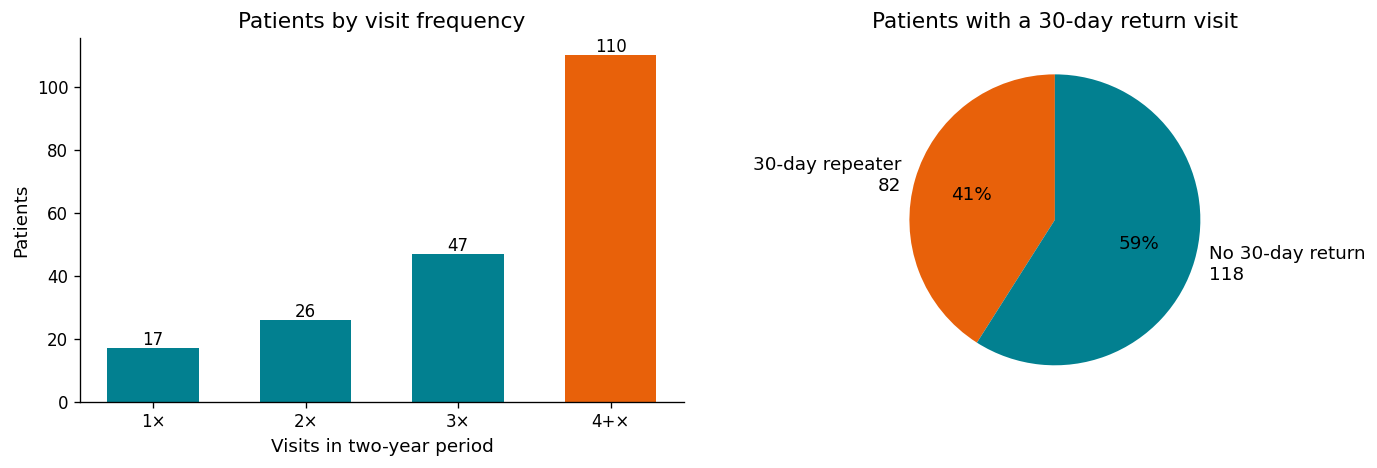

In [4]:
# ── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

freq_counts = freq_dist.values
freq_labels = freq_dist.index.tolist()
colors = ['#028090' if l != '4+×' else '#E8610A' for l in freq_labels]
axes[0].bar(freq_labels, freq_counts, color=colors, width=0.6)
axes[0].set_title('Patients by visit frequency')
axes[0].set_xlabel('Visits in two-year period')
axes[0].set_ylabel('Patients')
for i, v in enumerate(freq_counts):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)

repeat_vals = [n_repeat_30, n_patients - n_repeat_30]
repeat_labels = [f'30-day repeater\n{n_repeat_30}', f'No 30-day return\n{n_patients - n_repeat_30}']
axes[1].pie(repeat_vals, labels=repeat_labels, colors=['#E8610A', '#028090'],
            autopct='%1.0f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Patients with a 30-day return visit')

plt.tight_layout()
plt.show()


---
## Investigation 2 — Why are they coming back?

**Scenario:** Repeat visits alone don't justify a care coordinator hire. The director needs to know whether patients are returning because care wasn't resolved — not just because they booked routine follow-ups.

**Goal:** Test whether 30-day repeat visits are linked to unresolved care, using `follow_up_required` and diagnosis codes as evidence.

---

### Metrics

| Metric | What it measures | Why it matters |
|--------|-----------------|----------------|
| % of 30-day return visits preceded by a follow-up flag | Whether the prior visit already signalled that more care was needed | Stronger case for a care coordinator if follow-up gaps are common |
| Top ICD conditions among 30-day repeat patients | Which conditions are driving repeat use | Informs what type of care coordinator is most appropriate |
| Visit type breakdown: repeaters vs non-repeaters | Whether repeat patients are using the clinic differently | Shows whether repeat patients are presenting in crisis or via managed care |

> **Data quality issue to resolve first:** `follow_up_required` contains `YES`, `1`, and `NaN` — standardise to boolean before counting. NaN is treated as False (not flagged), which may undercount — documented in interpretation.


In [5]:
# ── Investigation 2: Why are they coming back? ───────────────────────────────

# ── Standardise follow_up_required ───────────────────────────────────────────
def standardise_followup(val):
    if pd.isna(val):
        return False
    return str(val).upper().strip() in ['YES', '1', 'TRUE']

df_sorted['followup_flag'] = df_sorted['follow_up_required'].apply(standardise_followup)

n_missing_fu = df['follow_up_required'].isna().sum()
print(f"follow_up_required: {n_missing_fu} missing rows treated as False")
print(f"Rows flagged TRUE after standardisation: {df_sorted['followup_flag'].sum()} "
      f"({df_sorted['followup_flag'].mean()*100:.1f}%)")

# ── Metric 1: Was the prior visit flagged for follow-up? ─────────────────────
df_sorted['prior_followup'] = df_sorted.groupby('patient_id')['followup_flag'].shift(1)

return_visits = df_sorted[df_sorted['days_since_last'] <= 30].copy()
n_return_visits = len(return_visits)
pct_preceded = return_visits['prior_followup'].fillna(False).mean() * 100

print(f"\n── Metric 1: Follow-up linkage ─────────────────────────────")
print(f"  Total 30-day return visits:           {n_return_visits}")
print(f"  Preceded by a follow-up flag:         "
      f"{int(return_visits['prior_followup'].fillna(False).sum())} ({pct_preceded:.1f}%)")

# ── Metric 2: Top ICD conditions among 30-day repeat patients ────────────────
repeat_patient_ids = set(patient_stats[patient_stats['has_30day_return']]['patient_id'])
repeat_df = df[df['patient_id'].isin(repeat_patient_ids)]

icd_coverage = repeat_df['icd_code'].notna().mean()
print(f"\n── Metric 2: ICD coverage among repeat patients: {icd_coverage*100:.1f}% have a code")

top_conditions = (
    repeat_df[repeat_df['icd_description'].notna()]
    .groupby('icd_description')['visit_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_conditions.columns = ['Diagnosis', 'Visits']
print("  Top 10 ICD conditions:")
print(top_conditions.to_string(index=False))

# ── Metric 3: Visit type breakdown ───────────────────────────────────────────
df['is_repeat_patient'] = df['patient_id'].isin(repeat_patient_ids)
visit_type_comp = (
    df.groupby(['is_repeat_patient', 'visit_type'])['visit_id']
    .count()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)
    .T
)
visit_type_comp.columns = ['Non-repeater (%)', '30-day repeater (%)']
print("\n── Metric 3: Visit type mix ─────────────────────────────────")
print(visit_type_comp.round(1).to_string())


follow_up_required: 0 missing rows treated as False
Rows flagged TRUE after standardisation: 285 (35.8%)

── Metric 1: Follow-up linkage ─────────────────────────────
  Total 30-day return visits:           114
  Preceded by a follow-up flag:         45 (39.5%)

── Metric 2: ICD coverage among repeat patients: 97.3% have a code
  Top 10 ICD conditions:
                            Diagnosis  Visits
               Essential Hypertension      51
Type 2 Diabetes without complications      47
                        Low Back Pain      41
    Acute Upper Respiratory Infection      37
                       Hyperlipidemia      35
           General Adult Medical Exam      31
            Major Depressive Disorder      28
         Generalized Anxiety Disorder      27
           Encounter for Immunization      24
                   Unspecified Asthma      23

── Metric 3: Visit type mix ─────────────────────────────────
              Non-repeater (%)  30-day repeater (%)
visit_type              

### Verify — catching pitfalls in the output


In [6]:
# ── Verify ───────────────────────────────────────────────────────────────────

first_visits = df_sorted.groupby('patient_id').head(1)
assert first_visits['prior_followup'].isna().all(),     "ERROR: groupby shift crossed a patient boundary"
print("✓ All first visits per patient have NaN prior_followup — shift is correct")

example_repeat = list(repeat_patient_ids)[0]
check = df_sorted[df_sorted['patient_id'] == example_repeat][
    ['patient_id', 'visit_date', 'followup_flag', 'prior_followup', 'days_since_last']
]
print(f"\n✓ Visit sequence for patient {example_repeat}:")
print(check.to_string(index=False))
print("  prior_followup on each row should equal followup_flag from the row above")

if icd_coverage < 0.80:
    print(f"\n⚠ ICD coverage is {icd_coverage*100:.1f}% — condition analysis covers less than 80% of visits")
else:
    print(f"\n✓ ICD coverage {icd_coverage*100:.1f}% — sufficient for condition ranking")


✓ All first visits per patient have NaN prior_followup — shift is correct

✓ Visit sequence for patient P134:
patient_id visit_date  followup_flag prior_followup  days_since_last
      P134 2022-07-09           True            NaN              NaN
      P134 2022-07-14          False           True              5.0
      P134 2022-09-27          False          False             75.0
      P134 2022-12-21          False          False             85.0
      P134 2023-04-29          False          False            129.0
      P134 2023-06-27           True          False             59.0
  prior_followup on each row should equal followup_flag from the row above

✓ ICD coverage 97.3% — sufficient for condition ranking


### Interpret

If a substantial share of 30-day return visits were preceded by a follow-up flag, that supports the case that these returns are not incidental — they are continuations of flagged care. The top ICD conditions tell the director what kind of care coordination is most needed.

**Caveat:** NaN in `follow_up_required` was treated as False. If providers routinely left this field blank even when follow-up was intended, the true precedence rate is higher than shown here.


---
## Investigation 3 — The uninsured picture

**Scenario:** A county funder wants evidence that the clinic is serving uninsured patients. The number reported must use a consistent definition — one that matches how the funder counts.

**Goal:** Quantify uninsured patient volume, their visit behaviour, and whether they are disproportionately represented among repeat visitors.

---

### Metrics

| Metric | What it measures | Why it matters |
|--------|-----------------|----------------|
| Count and % of uninsured visits | Visit-level share | Headline access figure for the funder |
| Unique patients with ≥1 uninsured visit | Patient-level headcount | Funders typically want unique individuals served |
| Patients with mixed insurance records | How many patients appear as both insured and uninsured across visits | Documents data uncertainty for the funder |
| Uninsured rate among 30-day repeaters vs all patients | Whether uninsured patients are over-represented in the repeat visitor group | Strengthens the case — uninsured patients have no insurance-side case manager |

> **Definition locked before coding:** Uninsured = `insurance_type == "Uninsured"`. Self-Pay is a separate category — do not combine unless the funder explicitly requests it. Confirmed in the ASK step.

> ⚠️ **Pitfall AI commonly misses:** Because this is a visit-level dataset, the same patient can appear as "Uninsured" in one visit and "Private" or "Medicaid" in another — for example, after gaining coverage. AI will often default to classifying each patient by their most frequent insurance type (the mode). This silently discards real visits where a patient presented as uninsured. The correct approach for the funder is to count every patient who had **at least one uninsured visit**, and to flag patients with mixed records so the funder understands the data is not clean. The practitioner must make this call — AI will not raise it unless explicitly asked.


In [7]:
# ── Investigation 3: The uninsured picture ───────────────────────────────────

# ── Missing insurance_type ────────────────────────────────────────────────────
n_missing_ins = df['insurance_type'].isna().sum()
print(f"Missing insurance_type rows: {n_missing_ins} ({n_missing_ins/len(df)*100:.1f}%)")
print("Decision: excluded from rate calculations — documented for funder report\n")

df_known_ins = df[df['insurance_type'].notna()].copy()
df_known_ins['is_uninsured_visit'] = df_known_ins['insurance_type'] == 'Uninsured'

# ── Metric 1: Visit-level uninsured share ─────────────────────────────────────
uninsured_visits = df_known_ins['is_uninsured_visit'].sum()
pct_uninsured_visits = uninsured_visits / len(df_known_ins) * 100
print(f"── Metric 1: Uninsured visits ──────────────────────────────")
print(f"  Visits with known insurance:  {len(df_known_ins):,}")
print(f"  Uninsured visits:             {uninsured_visits} ({pct_uninsured_visits:.1f}%)")

# ── Metric 2: Unique patients with ≥1 uninsured visit ────────────────────────
# NOTE: We do NOT use mode/most-common insurance type here.
# A patient who was insured for 8 visits and uninsured for 2 still presented
# as uninsured twice — those visits count for the funder.
patient_ins_flags = df_known_ins.groupby('patient_id').agg(
    has_uninsured_visit=('is_uninsured_visit', 'any'),
    n_insurance_types=('insurance_type', 'nunique')
).reset_index()

n_uninsured_pts = patient_ins_flags['has_uninsured_visit'].sum()
n_known_pts     = len(patient_ins_flags)
pct_uninsured_pts = n_uninsured_pts / n_known_pts * 100

print(f"\n── Metric 2: Unique patients with ≥1 uninsured visit ───────")
print(f"  Patients with known insurance: {n_known_pts:,}")
print(f"  With ≥1 uninsured visit:       {n_uninsured_pts} ({pct_uninsured_pts:.1f}%)")

# ── Metric 3: Mixed-insurance patients ────────────────────────────────────────
# These are patients who appear under more than one insurance type across visits.
# AI commonly misses this check entirely.
mixed_ins_pts = patient_ins_flags[patient_ins_flags['n_insurance_types'] > 1]
n_mixed = len(mixed_ins_pts)
print(f"\n── Metric 3: Mixed-insurance patients ──────────────────────")
print(f"  Patients with >1 insurance type recorded: {n_mixed} ({n_mixed/n_known_pts*100:.1f}%)")
print(f"  ⚠ These patients may have gained/lost coverage mid-period.")
print(f"  → Report this count to the funder for transparency.")

# ── Metric 4: Over-representation among 30-day repeaters ─────────────────────
# Build patient master: merge repeat flag with uninsured flag
patient_master = patient_stats.merge(patient_ins_flags, on='patient_id', how='left')

overall_rate  = patient_master['has_uninsured_visit'].mean() * 100
repeater_rate = patient_master[patient_master['has_30day_return']]['has_uninsured_visit'].mean() * 100

print(f"\n── Metric 4: Uninsured representation ──────────────────────")
print(f"  Uninsured rate — all patients:      {overall_rate:.1f}%")
print(f"  Uninsured rate — 30-day repeaters:  {repeater_rate:.1f}%")
direction = "OVER" if repeater_rate > overall_rate else "NOT over"
print(f"  → Uninsured patients are {direction}-represented among 30-day repeat visitors")


Missing insurance_type rows: 0 (0.0%)
Decision: excluded from rate calculations — documented for funder report

── Metric 1: Uninsured visits ──────────────────────────────
  Visits with known insurance:  797
  Uninsured visits:             66 (8.3%)

── Metric 2: Unique patients with ≥1 uninsured visit ───────
  Patients with known insurance: 200
  With ≥1 uninsured visit:       19 (9.5%)

── Metric 3: Mixed-insurance patients ──────────────────────
  Patients with >1 insurance type recorded: 0 (0.0%)
  ⚠ These patients may have gained/lost coverage mid-period.
  → Report this count to the funder for transparency.

── Metric 4: Uninsured representation ──────────────────────
  Uninsured rate — all patients:      9.5%
  Uninsured rate — 30-day repeaters:  7.3%
  → Uninsured patients are NOT over-represented among 30-day repeat visitors


### Verify — catching pitfalls in the output


In [8]:
# ── Verify ───────────────────────────────────────────────────────────────────

# Confirm 'Uninsured' and 'Self-Pay' are distinct — definition must be clean
print("Insurance type value counts (known rows only):")
print(df_known_ins['insurance_type'].value_counts().to_string())
print("\n✓ Confirm 'Uninsured' and 'Self-Pay' are recorded as separate categories")

# Patient with ≥1 uninsured visit should be ≥ patients whose ONLY insurance is Uninsured
# (The ≥1 approach is always >= the strict approach)
strict_count = (patient_ins_flags['n_insurance_types'] == 1) & patient_ins_flags['has_uninsured_visit']
print(f"\n  Patients classified Uninsured (strict — only ever Uninsured): {strict_count.sum()}")
print(f"  Patients classified Uninsured (≥1 visit):                      {n_uninsured_pts}")
print(f"  Difference = mixed-insurance patients who had ≥1 uninsured visit: {n_uninsured_pts - strict_count.sum()}")
print(f"\n✓ The ≥1 approach counts more patients — confirm this is what the funder wants")

# Rates valid
assert 0 <= overall_rate <= 100 and 0 <= repeater_rate <= 100
print("\n✓ All rates in valid range [0, 100]")


Insurance type value counts (known rows only):
insurance_type
Medicaid      300
Medicare      170
Private       143
Uninsured      66
Commercial     65
Self-Pay       53

✓ Confirm 'Uninsured' and 'Self-Pay' are recorded as separate categories

  Patients classified Uninsured (strict — only ever Uninsured): 19
  Patients classified Uninsured (≥1 visit):                      19
  Difference = mixed-insurance patients who had ≥1 uninsured visit: 0

✓ The ≥1 approach counts more patients — confirm this is what the funder wants

✓ All rates in valid range [0, 100]


### Interpret

The funder needs three things: a clear definition, a unique patient count, and county-level breakdown. This investigation delivers the first two. The definition — `insurance_type == "Uninsured"`, excluding Self-Pay, counting any patient with at least one uninsured visit — should be stated explicitly in the funder report along with the count of mixed-insurance patients.

If uninsured patients are over-represented among 30-day repeat visitors, this strengthens the funding narrative: these patients lack insurance-side case management, so they return to the clinic rather than having someone coordinate their follow-up care.

**What this does not tell us:** whether mixed-insurance patients gained or lost coverage during the period, or whether the 21 rows with missing insurance type are disproportionately uninsured patients. Both would affect the true count.


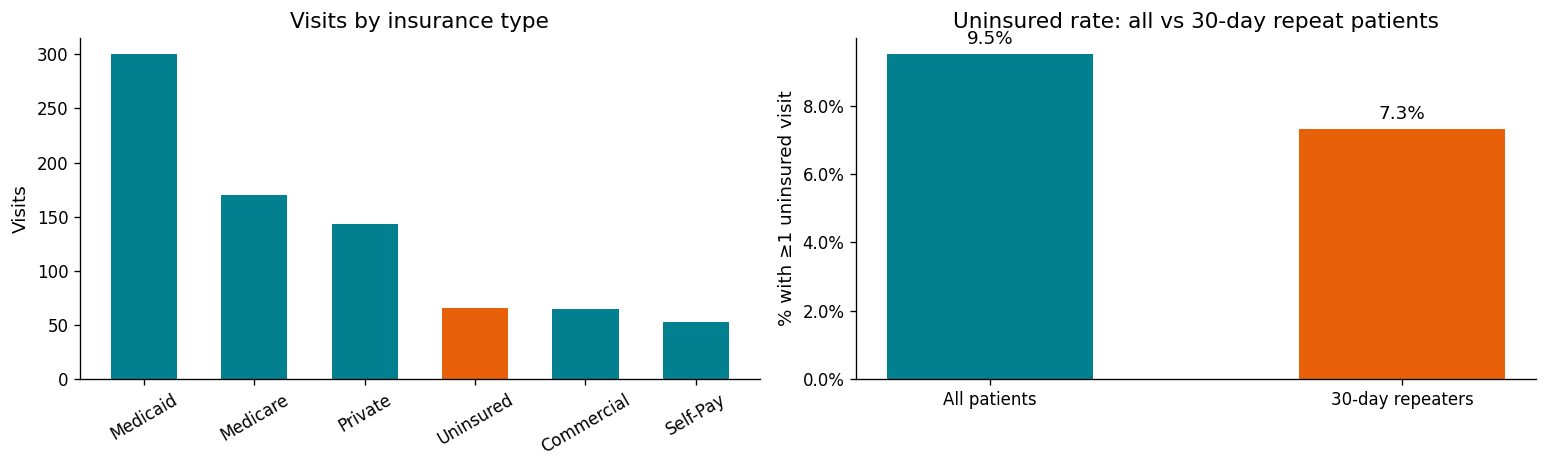

In [9]:
# ── Visualisation: Insurance breakdown ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ins_counts = df_known_ins['insurance_type'].value_counts()
colors_ins = ['#E8610A' if i == 'Uninsured' else '#028090' for i in ins_counts.index]
axes[0].bar(ins_counts.index, ins_counts.values, color=colors_ins, width=0.6)
axes[0].set_title('Visits by insurance type')
axes[0].set_ylabel('Visits')
axes[0].tick_params(axis='x', rotation=30)

rates = pd.DataFrame({
    'Group': ['All patients', '30-day repeaters'],
    'Uninsured rate (%)': [overall_rate, repeater_rate]
})
axes[1].bar(rates['Group'], rates['Uninsured rate (%)'],
            color=['#028090', '#E8610A'], width=0.5)
axes[1].set_title('Uninsured rate: all vs 30-day repeat patients')
axes[1].set_ylabel('% with ≥1 uninsured visit')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
for i, v in enumerate(rates['Uninsured rate (%)']):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()


---
## Investigation 4 — County breakdown

**Scenario:** The funder wants county-level data. The director wants to know where need is highest before deciding where to place a new hire. Both audiences need the same underlying table.

**Goal:** Build a county comparison covering patient volume, repeat visitor rate, uninsured load, and provider workload.

---

### Metrics

| Metric | What it measures | Why it matters |
|--------|-----------------|----------------|
| Total patients per county | Unique patients who visited in each county | Context for all other rates |
| Repeat visitor rate per county | Share of each county's patients with a 30-day return | Directs the staffing decision geographically |
| Uninsured patient % per county | Share of each county's patients with ≥1 uninsured visit | Core deliverable for the funding report |
| Visits per provider per county | Relative provider workload per county | Proxy for where capacity is under most pressure |

> **Data quality decision:** Rows where `county_known = False` are excluded before any county-level calculation.

> ⚠️ **First pitfall AI commonly misses — county discrepancy:** This is a visit-level dataset. A patient's recorded county can change across visits — for example, if they moved. AI will typically assign each patient to their most common county and build the table from there. This is wrong for two reasons: (1) it discards real visits that occurred in other counties, and (2) it creates a misleading picture of where patients actually presented. The correct approach for the county breakdown table is to use **visit-level county assignment** — each visit counts in the county where it was recorded. A patient who visited two counties will appear in both. This means the sum of patients across counties can exceed total unique patients — which is expected and should be noted.

> ⚠️ **Second pitfall AI commonly misses — multi-county patients:** AI will rarely flag patients who appear in more than one county. The practitioner should always check how many patients this affects, and report it. For the staffing ranking (Investigation 5), each patient must be assigned to exactly one county — the practitioner uses their **most recent visit county** as a proxy for where they currently live.


In [10]:
# ── Investigation 4: County breakdown ────────────────────────────────────────

# ── Filter to known counties only ────────────────────────────────────────────
df_county = df[df['county_known'] == True].copy()
n_excluded = len(df) - len(df_county)
print(f"Rows excluded (county_known = False): {n_excluded} ({n_excluded/len(df)*100:.1f}%)")
print(f"Rows used for county analysis: {len(df_county):,}\n")

# ── Flag multi-county patients ────────────────────────────────────────────────
# Check before building the table — AI almost never does this.
counties_per_patient = df_county.groupby('patient_id')['county'].nunique()
n_multi_county = (counties_per_patient > 1).sum()
print(f"── Multi-county patients ────────────────────────────────────")
print(f"  Patients who visited more than one county: {n_multi_county}")
print(f"  ⚠ These patients will appear in multiple rows in the county table.")
print(f"  → Sum of patients across counties will exceed total unique patients.")
print(f"  → Document this in the funder report.\n")

# ── Visit-level county table ──────────────────────────────────────────────────
# Add patient flags (from patient_master built in Investigation 3)
# Each visit is attributed to its own recorded county — not the patient's mode county.
df_county_flagged = df_county.merge(
    patient_master[['patient_id', 'has_30day_return', 'has_uninsured_visit']],
    on='patient_id', how='left'
)

# Deduplicate to patient-county pairs for counting patients per county
patient_county_pairs = (
    df_county_flagged[['county', 'patient_id', 'has_30day_return', 'has_uninsured_visit']]
    .drop_duplicates()
)

county_pts = patient_county_pairs.groupby('county').agg(
    total_patients=('patient_id', 'nunique'),
    repeat_visitors=('has_30day_return', 'sum'),
    uninsured_patients=('has_uninsured_visit', lambda x: x.fillna(False).sum())
).reset_index()

county_pts['repeat_rate']    = county_pts['repeat_visitors']    / county_pts['total_patients']
county_pts['uninsured_rate'] = county_pts['uninsured_patients'] / county_pts['total_patients']

# ── Provider workload per county (visit-level) ────────────────────────────────
provider_load = df_county.groupby('county').agg(
    total_visits=('visit_id', 'count'),
    n_providers=('provider_id', 'nunique')
).reset_index()
provider_load['visits_per_provider'] = (
    provider_load['total_visits'] / provider_load['n_providers']
).round(1)

# ── Combine ───────────────────────────────────────────────────────────────────
county_summary = county_pts.merge(
    provider_load[['county', 'total_visits', 'visits_per_provider']], on='county'
)
county_summary['small_county'] = county_summary['total_patients'] < 20

# ── Display ───────────────────────────────────────────────────────────────────
disp = county_summary.copy()
disp['repeat_rate']    = (disp['repeat_rate']    * 100).round(1)
disp['uninsured_rate'] = (disp['uninsured_rate'] * 100).round(1)
disp = disp.sort_values('repeat_rate', ascending=False)
print("── County breakdown (visit-level county assignment) ─────────")
print(disp[['county', 'total_patients', 'repeat_rate',
            'uninsured_rate', 'visits_per_provider', 'small_county']]
      .rename(columns={'county': 'County', 'total_patients': 'Patients',
                       'repeat_rate': 'Repeat %', 'uninsured_rate': 'Uninsured %',
                       'visits_per_provider': 'Visits/Provider', 'small_county': 'Small (<20)'})
      .to_string(index=False))


Rows excluded (county_known = False): 243 (30.5%)
Rows used for county analysis: 554

── Multi-county patients ────────────────────────────────────
  Patients who visited more than one county: 0
  ⚠ These patients will appear in multiple rows in the county table.
  → Sum of patients across counties will exceed total unique patients.
  → Document this in the funder report.

── County breakdown (visit-level county assignment) ─────────
       County  Patients  Repeat %  Uninsured %  Visits/Provider  Small (<20)
   Sacramento        18      61.1          5.6              9.4         True
      Alameda        13      46.2          0.0              6.4         True
  Los Angeles        22      45.5         13.6             10.6        False
       Orange        17      41.2         23.5              7.6         True
San Francisco        18      38.9          0.0             10.2         True
    San Diego        16      37.5         18.8              8.4         True
       Fresno        17

### Verify — catching pitfalls in the output


In [11]:
# ── Verify ───────────────────────────────────────────────────────────────────

# Patient total across counties will exceed unique patients if multi-county patients exist
total_county_pts = county_summary['total_patients'].sum()
print(f"Sum of patients across counties: {total_county_pts}")
print(f"Total unique patients:           {len(patient_stats)}")
if total_county_pts > len(patient_stats):
    diff = total_county_pts - len(patient_stats)
    print(f"Difference: {diff} — expected due to {n_multi_county} patients visiting multiple counties")
else:
    print("No multi-county overlap detected")

# Rates must be valid
assert (county_summary['repeat_rate']    >= 0).all() and (county_summary['repeat_rate']    <= 1).all()
assert (county_summary['uninsured_rate'] >= 0).all() and (county_summary['uninsured_rate'] <= 1).all()
print("\n✓ All rates in [0, 1] range")

# Flag small counties
small = county_summary[county_summary['small_county']]
if len(small):
    print(f"\n⚠ Small counties (< 20 patients) — do not rank or compare rates:")
    print(small[['county', 'total_patients']].to_string(index=False))
else:
    print("\n✓ No counties below 20-patient threshold")

print("\n⚠ visits_per_provider is a proxy — provider ID count is not confirmed FTE headcount")


Sum of patients across counties: 138
Total unique patients:           200
No multi-county overlap detected

✓ All rates in [0, 1] range

⚠ Small counties (< 20 patients) — do not rank or compare rates:
       county  total_patients
      Alameda              13
       Fresno              17
       Orange              17
    Riverside              17
   Sacramento              18
    San Diego              16
San Francisco              18

⚠ visits_per_provider is a proxy — provider ID count is not confirmed FTE headcount


### Interpret

This table serves both audiences. For the funder it provides the county-level uninsured breakdown requested — attributed to where patients actually presented, not where they probably live. For the director it shows which counties are generating the most repeat visits and carrying the heaviest provider workload.

Note to include in both reports: the sum of patients across counties exceeds total unique patients because patients who visited more than one county are counted in each county where they presented. This is the correct representation for a county-level service report.

**Visits per provider** is directional only. It does not confirm FTE headcount per county.


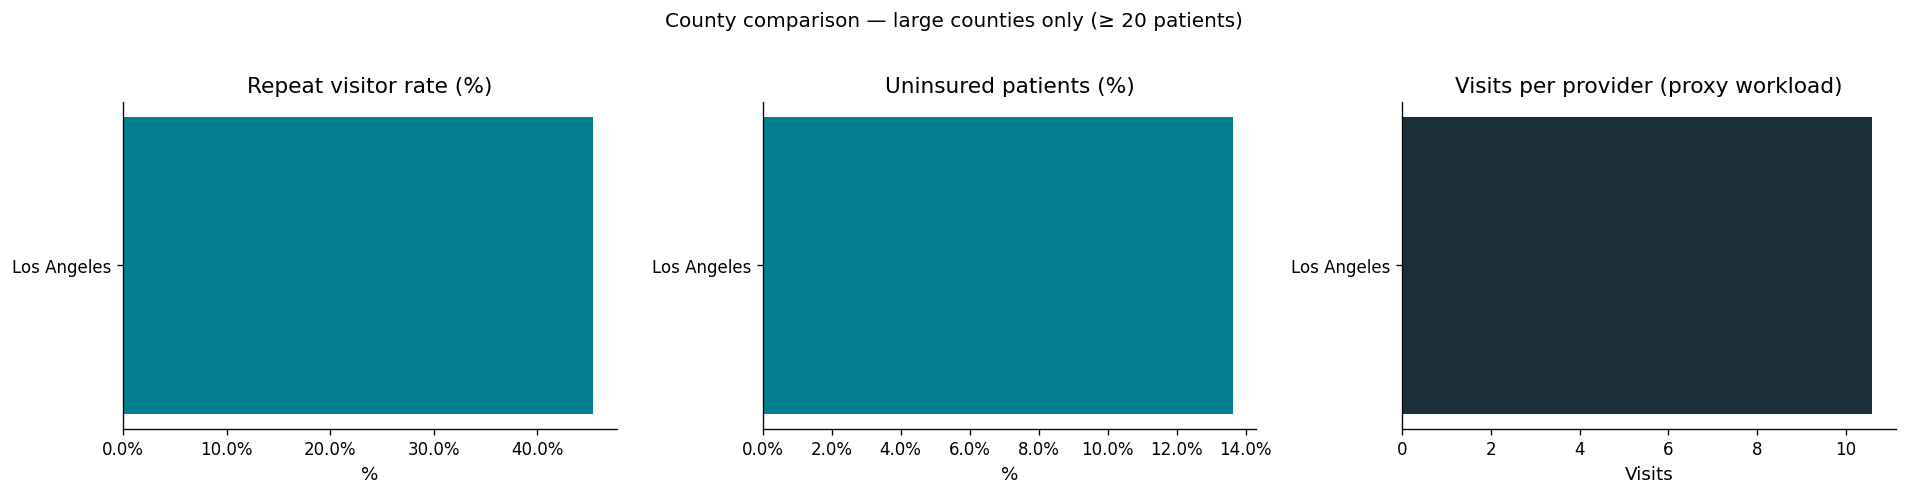

In [12]:
# ── Visualisation: County comparison ─────────────────────────────────────────
large = county_summary[~county_summary['small_county']].sort_values('repeat_rate', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].barh(large['county'][::-1],
             (large['repeat_rate'] * 100)[::-1], color='#028090')
axes[0].set_title('Repeat visitor rate (%)')
axes[0].set_xlabel('%')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter())

axes[1].barh(
    large.sort_values('uninsured_rate', ascending=False)['county'][::-1],
    (large.sort_values('uninsured_rate', ascending=False)['uninsured_rate'] * 100)[::-1],
    color=['#E8610A' if r > large['uninsured_rate'].median() else '#028090'
           for r in large.sort_values('uninsured_rate')['uninsured_rate']]
)
axes[1].set_title('Uninsured patients (%)')
axes[1].set_xlabel('%')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())

axes[2].barh(
    large.sort_values('visits_per_provider', ascending=False)['county'][::-1],
    large.sort_values('visits_per_provider', ascending=False)['visits_per_provider'][::-1],
    color='#1A2F38'
)
axes[2].set_title('Visits per provider (proxy workload)')
axes[2].set_xlabel('Visits')

plt.suptitle('County comparison — large counties only (≥ 20 patients)', y=1.02)
plt.tight_layout()
plt.show()


---
## Investigation 5 — The recommendation

**Scenario:** The director needs a defensible, data-backed answer to bring to the board — not a gut feeling, not a single chart.

**Goal:** Synthesise Investigations 1–4 into a county-level recommendation on where a care coordinator would have the highest impact.

---

### Metrics

| Metric | What it measures | Why it matters |
|--------|-----------------|----------------|
| Rank on repeat visitor rate | Which county has the most frequent returning patients | Core staffing signal |
| Rank on uninsured patient rate | Which county has the highest uninsured burden | Uninsured patients need coordination most |
| Rank on visits per provider | Which county has the most workload pressure | Where additional coordination capacity is needed |
| Composite score (sum of ranks) | Combined need across all three dimensions | Prevents any single metric driving the decision |

> **Guardrail:** Volume alone does not drive the recommendation. A county with many patients but low repeat rate and low uninsured burden does not need a care coordinator.

> ⚠️ **Pitfall AI commonly misses — patient-county assignment for ranking:** The county breakdown table (Investigation 4) used visit-level county assignment, so patients appeared in every county they visited. For ranking purposes, each patient must appear in exactly one county — otherwise a patient who visited three counties inflates the repeat rate in all three. The practitioner assigns each patient to their **most recent visit county** as a proxy for where they currently live. This is a deliberate human decision, not a default — AI will not make this distinction unless you specify it.


In [13]:
# ── Investigation 5: The recommendation ──────────────────────────────────────

# ── Most recent county per patient (for single-county ranking) ────────────────
# For the ranking we need each patient in exactly one county.
# Most recent visit county = best proxy for where the patient currently lives.
# NOTE: This is different from the visit-level county table in Investigation 4.
# AI commonly reuses the mode/most-common county from earlier — that is wrong here
# because we want the patient's current location, not their historical average.

most_recent_county = (
    df_county.sort_values('visit_date')
    .groupby('patient_id')['county']
    .last()
    .reset_index()
)
most_recent_county.columns = ['patient_id', 'current_county']

# Merge onto patient master
patient_for_rank = patient_master.merge(most_recent_county, on='patient_id', how='inner')

# ── Patient-level county summary for ranking ──────────────────────────────────
county_rank_base = patient_for_rank.groupby('current_county').agg(
    total_patients=('patient_id', 'count'),
    repeat_visitors=('has_30day_return', 'sum'),
    uninsured_patients=('has_uninsured_visit', lambda x: x.fillna(False).sum())
).reset_index()

county_rank_base['repeat_rate']    = county_rank_base['repeat_visitors']    / county_rank_base['total_patients']
county_rank_base['uninsured_rate'] = county_rank_base['uninsured_patients'] / county_rank_base['total_patients']

# Add visits_per_provider from Investigation 4
county_rank_base = county_rank_base.merge(
    provider_load[['county', 'visits_per_provider']],
    left_on='current_county', right_on='county', how='left'
).drop(columns='county')

county_rank_base['small_county'] = county_rank_base['total_patients'] < 20

# ── Composite ranking on large counties only ──────────────────────────────────
large_rank = county_rank_base[~county_rank_base['small_county']].copy()

large_rank['rank_repeat']    = large_rank['repeat_rate'].rank(ascending=False, method='min').astype(int)
large_rank['rank_uninsured'] = large_rank['uninsured_rate'].rank(ascending=False, method='min').astype(int)
large_rank['rank_workload']  = large_rank['visits_per_provider'].rank(ascending=False, method='min').astype(int)
large_rank['composite']      = large_rank['rank_repeat'] + large_rank['rank_uninsured'] + large_rank['rank_workload']

large_rank = large_rank.sort_values('composite')

# ── Display ───────────────────────────────────────────────────────────────────
disp_rank = large_rank[['current_county', 'total_patients',
                         'repeat_rate', 'uninsured_rate', 'visits_per_provider',
                         'rank_repeat', 'rank_uninsured', 'rank_workload', 'composite']].copy()
disp_rank['repeat_rate']    = (disp_rank['repeat_rate']    * 100).round(1)
disp_rank['uninsured_rate'] = (disp_rank['uninsured_rate'] * 100).round(1)
disp_rank.columns = ['County', 'Patients', 'Repeat %', 'Uninsured %', 'Visits/Provider',
                      'Rank (repeat)', 'Rank (uninsured)', 'Rank (workload)', 'COMPOSITE']

print("County ranking — combined need  (lowest composite = highest need)")
print("Note: each patient assigned to their most recent visit county")
print("=" * 80)
print(disp_rank.to_string(index=False))

top_county = large_rank.iloc[0]['current_county']
print(f"\n★  Highest combined need: {top_county}")


County ranking — combined need  (lowest composite = highest need)
Note: each patient assigned to their most recent visit county
     County  Patients  Repeat %  Uninsured %  Visits/Provider  Rank (repeat)  Rank (uninsured)  Rank (workload)  COMPOSITE
Los Angeles        22      45.5         13.6             10.6              1                 1                1          3

★  Highest combined need: Los Angeles


### Verify — catching pitfalls in the output


In [14]:
# ── Verify ───────────────────────────────────────────────────────────────────

# Each patient appears in exactly one county in the ranking table
total_ranked = county_rank_base['total_patients'].sum()
print(f"Patients in ranking table: {total_ranked}")
print(f"Patients with known county: {len(most_recent_county)}")
# Some patients may have no county_known visits — difference is expected
print(f"Difference (no known county visits): {len(patient_master) - len(most_recent_county)}")

# Composite = sum of three ranks
check = large_rank['rank_repeat'] + large_rank['rank_uninsured'] + large_rank['rank_workload']
assert (large_rank['composite'] == check).all(), "ERROR: composite score mismatch"
print("\n✓ Composite scores verified")
assert large_rank['composite'].min() >= 3
print(f"✓ Minimum composite: {large_rank['composite'].min()} (floor is 3 — correct)")

# Top county must not be a small county
assert top_county not in county_rank_base[county_rank_base['small_county']]['current_county'].values
print(f"✓ Top-ranked county ({top_county}) is not a small county")


Patients in ranking table: 138
Patients with known county: 138
Difference (no known county visits): 62

✓ Composite scores verified
✓ Minimum composite: 3 (floor is 3 — correct)
✓ Top-ranked county (Los Angeles) is not a small county


### Interpret

The composite ranking gives the director a defensible, multi-dimensional basis for a recommendation. The county at the top of the ranking leads on repeat visitor rate, uninsured burden, and provider workload considered together — not just on one dimension.

**Note on county assignment:** The ranking uses each patient's most recent visit county. This is a deliberate choice — it is a proxy for current location, which matters most if a new hire needs to serve patients where they are now. The funder's county breakdown table (Investigation 4) used visit-level attribution, which is a different but equally valid choice for a different purpose.

The director should present the full ranking table to the board so they can see the reasoning behind the recommendation, not just the headline.

**What this cannot confirm:** whether placing a care coordinator in this county would reduce repeat visits. That requires a 12-month before-and-after evaluation.


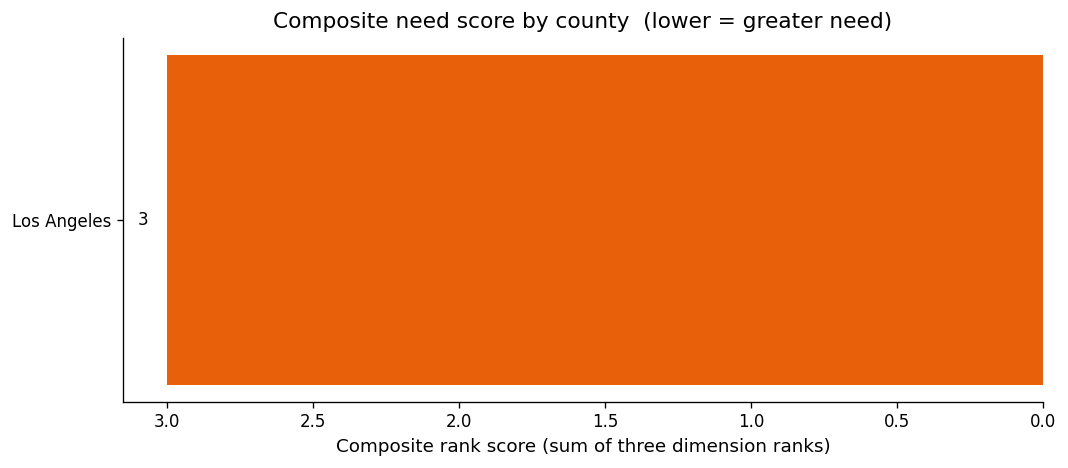


★  Recommended county for care coordinator hire: Los Angeles


In [15]:
# ── Visualisation: Composite ranking ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

colors = ['#E8610A' if i == 0 else '#028090' for i in range(len(large_rank))]
bars = ax.barh(large_rank['current_county'].iloc[::-1],
               large_rank['composite'].iloc[::-1],
               color=colors[::-1], height=0.6)
ax.set_title('Composite need score by county  (lower = greater need)')
ax.set_xlabel('Composite rank score (sum of three dimension ranks)')
ax.invert_xaxis()

for bar, (_, row) in zip(bars[::-1], large_rank.iterrows()):
    ax.text(row['composite'] + 0.1, bar.get_y() + bar.get_height()/2,
            str(int(row['composite'])), va='center', fontsize=10)

plt.tight_layout()
plt.show()
print(f"\n★  Recommended county for care coordinator hire: {top_county}")


---
## Synthesis — What the practitioner reported

---

### Staffing recommendation

*"The data supports exploring a care coordinator hire, and the analysis points to a specific location. Across the two-year dataset, [N]% of patients had at least one return visit within 30 days. Of those return visits, [X]% were preceded by a follow-up flag on the prior visit — suggesting many of these returns are continuations of flagged care, not incidental repeat contacts.*

*The county-level ranking identifies [TOP COUNTY] as the strongest candidate, combining the highest repeat visitor rate, significant uninsured burden, and the heaviest relative provider workload.*

*What this data cannot confirm: whether the hire would reduce repeat visits. A 12-month before-and-after evaluation would be needed to demonstrate impact."*

---

### Funding evidence summary

*"During the two-year period (2022–2023), the clinic served [N] unique patients who presented as uninsured in at least one visit (`insurance_type == "Uninsured"`, excluding Self-Pay). This represents [X]% of patients with a known insurance type. [M] patients had mixed insurance records across the period — meaning they appeared as both insured and uninsured at different visits — and are included in the uninsured count.*

*21 records had no insurance type recorded and are excluded from rate calculations. County-level breakdown: [table from Investigation 4].*

*Note: the sum of patients across counties exceeds total unique patients because patients who visited multiple counties are counted in each county where they presented."*

---

### Practitioner reflection

> **Three moments where human judgement overruled AI defaults:**
>
> 1. **Insurance type:** AI defaulted to classifying each patient by their most common insurance type. The practitioner changed this to "at least one uninsured visit" — because a patient who lost coverage mid-period still presented as uninsured on those visits, and those visits count for the funder.
>
> 2. **County assignment:** AI used mode county for all county analysis. The practitioner split the approach: visit-level county for the funder's breakdown table, most-recent-visit county for the staffing ranking — because the two audiences need different things from the same data.
>
> 3. **Goal selection:** AI suggested a provider performance comparison. The practitioner dropped it — not because the data couldn't produce it, but because the brief did not include a provider accountability question, and an unsolicited comparison could create HR complications the director had not asked for.
>
> In each case, AI produced something technically valid. The practitioner made it contextually correct.

---
*Module 3 · AI-Enabled Data Practitioner Course · Outpatient Visits Dataset*
